W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
적용 폰트: NanumGothic


Saving 공공도서관_20260621161743.xlsx to 공공도서관_20260621161743 (1).xlsx

분석 데이터


,자치구,도서관 방문자수,연간대출 책수,방문자수 대비 연간대출 책수
4,종로구,2863473,862801,0.301313
5,중구,1805354,771261,0.427208
6,용산구,2158042,636404,0.294899
7,성동구,2072880,838097,0.404315
8,광진구,2671211,1297032,0.485560
9,동대문구,1910883,1086377,0.568521
10,중랑구,1570328,764317,0.486724
11,성북구,1596741,793410,0.496893
12,강북구,447951,450502,1.005695
13,도봉구,1569302,739175,0.471022


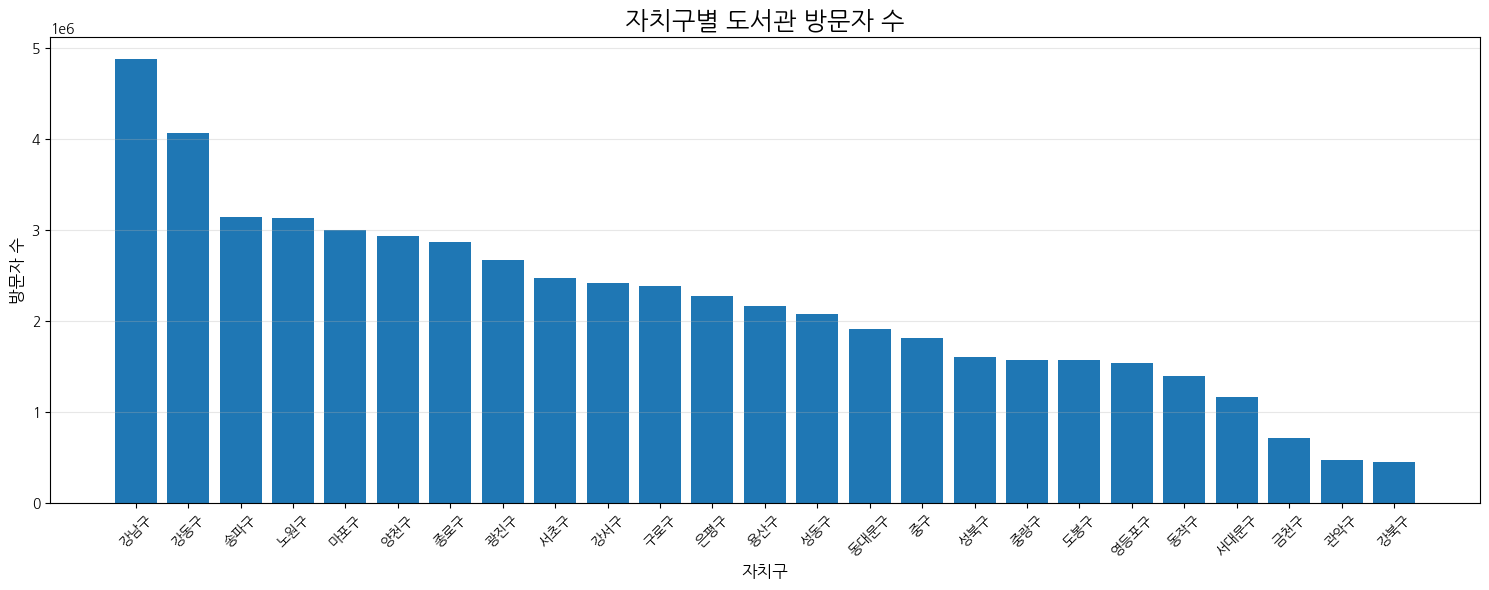

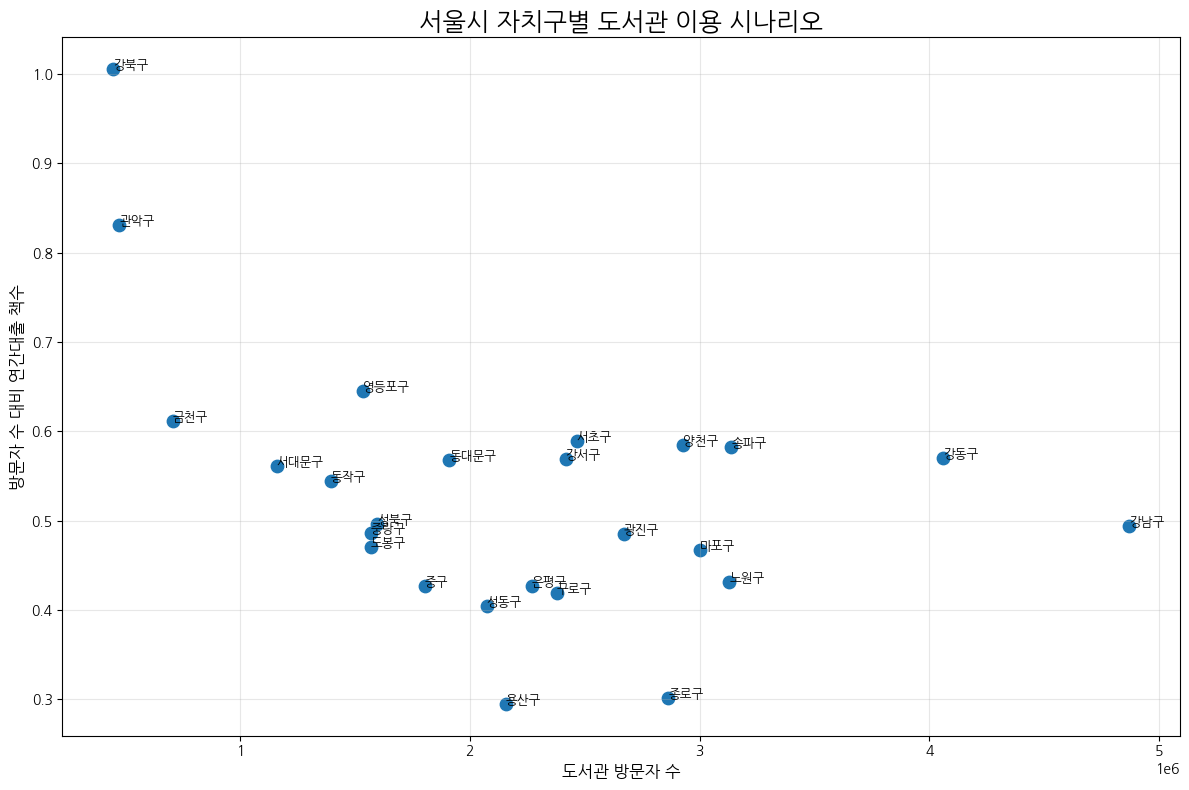

In [ ]:

# ============================================================
# 공공도서관 데이터 분석 / Google Colab
# ============================================================

!apt-get -qq update
!apt-get -qq install -y fonts-nanum
!fc-cache -fv > /dev/null 2>&1
!rm -rf ~/.cache/matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 1. 한글 폰트 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("적용 폰트:", font_name)

# ============================================================
# 2. 파일 업로드
# ============================================================

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# ============================================================
# 3. 엑셀 구조에 맞게 데이터 읽기
# ============================================================

raw = pd.read_excel(file_name, sheet_name="데이터", header=None)

df = raw.iloc[4:, [0, 1, 2]].copy()
df.columns = ["자치구", "도서관 방문자수", "연간대출 책수"]

df["자치구"] = (
    df["자치구"]
    .astype(str)
    .str.replace("\u3000", "", regex=False)
    .str.strip()
)

df["도서관 방문자수"] = pd.to_numeric(df["도서관 방문자수"], errors="coerce")
df["연간대출 책수"] = pd.to_numeric(df["연간대출 책수"], errors="coerce")

df = df.dropna()
df = df[df["자치구"] != "합계"]

df["방문자수 대비 연간대출 책수"] = df["연간대출 책수"] / df["도서관 방문자수"]

print("\n분석 데이터")
display(df)

# ============================================================
# 4. 자치구별 도서관 방문자 수 내림차순 막대그래프
# ============================================================

bar_df = df.sort_values("도서관 방문자수", ascending=False)

plt.figure(figsize=(15, 6))

plt.bar(
    bar_df["자치구"],
    bar_df["도서관 방문자수"]
)

plt.title(
    "자치구별 도서관 방문자 수",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("자치구", fontsize=12)
plt.ylabel("방문자 수", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 5. 서울시 자치구별 도서관 이용 시나리오 산점도
# ============================================================

plt.figure(figsize=(12, 8))

plt.scatter(
    df["도서관 방문자수"],
    df["방문자수 대비 연간대출 책수"],
    s=80
)

for _, row in df.iterrows():
    plt.text(
        row["도서관 방문자수"],
        row["방문자수 대비 연간대출 책수"],
        row["자치구"],
        fontsize=9
    )

plt.title(
    "서울시 자치구별 도서관 이용 시나리오",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("도서관 방문자 수", fontsize=12)
plt.ylabel("방문자 수 대비 연간대출 책수", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()